# Bitcoin Data Prep

This notebook goes through my data exploration steps and any data cleaning/prep I did prior to modeling. 

In [1]:
# Import the paackages used in this notebook
import pandas as pd 
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
# Read in the data from Coursera 
bitcoin_df = pd.read_csv("data/bitcoin.csv")

## Understand the Data

In [3]:
# Get column names
bitcoin_df.columns

Index(['Date', 'btc_market_price', 'btc_total_bitcoins', 'btc_market_cap',
       'btc_trade_volume', 'btc_blocks_size', 'btc_avg_block_size',
       'btc_n_orphaned_blocks', 'btc_n_transactions_per_block',
       'btc_median_confirmation_time', 'btc_hash_rate', 'btc_difficulty',
       'btc_miners_revenue', 'btc_transaction_fees',
       'btc_cost_per_transaction_percent', 'btc_cost_per_transaction',
       'btc_n_unique_addresses', 'btc_n_transactions',
       'btc_n_transactions_total', 'btc_n_transactions_excluding_popular',
       'btc_n_transactions_excluding_chains_longer_than_100',
       'btc_output_volume', 'btc_estimated_transaction_volume',
       'btc_estimated_transaction_volume_usd'],
      dtype='object')

In [4]:
# Get a preview of each of the columns in a readable format: 
cols = bitcoin_df.columns
for i in range(0, len(cols), 3):
    subset = cols[i:i+3]
    print(bitcoin_df[subset].describe())
    print("\n" + "="*80 + "\n")  

       btc_market_price  btc_total_bitcoins
count       2920.000000        2.920000e+03
mean         897.485562        1.152051e+07
std         2400.159935        4.200938e+06
min            0.000000        2.110700e+06
25%            6.768750        8.405100e+06
50%          236.310000        1.242910e+07
75%          603.909050        1.523764e+07
max        19498.683333        1.687682e+07


       btc_market_cap  btc_trade_volume  btc_blocks_size
count    2.920000e+03      2.899000e+03      2920.000000
mean     1.443022e+10      8.231157e+07     36058.374765
std      4.029263e+10      3.116642e+08     44536.901058
min      0.000000e+00      0.000000e+00         0.000000
25%      5.560588e+07      2.994316e+05       777.250000
50%      3.364730e+09      1.024364e+07     15132.000000
75%      8.210042e+09      2.934823e+07     59301.750000
max      3.265254e+11      5.352016e+09    157664.996336


       btc_avg_block_size  btc_n_orphaned_blocks  btc_n_transactions_per_block
count   

In [5]:
# See the data types of each column 
bitcoin_df.dtypes

Date                                                    object
btc_market_price                                       float64
btc_total_bitcoins                                     float64
btc_market_cap                                         float64
btc_trade_volume                                       float64
btc_blocks_size                                        float64
btc_avg_block_size                                     float64
btc_n_orphaned_blocks                                  float64
btc_n_transactions_per_block                           float64
btc_median_confirmation_time                           float64
btc_hash_rate                                          float64
btc_difficulty                                         float64
btc_miners_revenue                                     float64
btc_transaction_fees                                   float64
btc_cost_per_transaction_percent                       float64
btc_cost_per_transaction                               

## Find Missing Values

In [6]:
# Identify columns that have missing values
bitcoin_df.isnull().sum()

Date                                                    0
btc_market_price                                        0
btc_total_bitcoins                                      0
btc_market_cap                                          0
btc_trade_volume                                       21
btc_blocks_size                                         0
btc_avg_block_size                                      0
btc_n_orphaned_blocks                                   0
btc_n_transactions_per_block                            0
btc_median_confirmation_time                            0
btc_hash_rate                                           0
btc_difficulty                                          0
btc_miners_revenue                                      0
btc_transaction_fees                                    0
btc_cost_per_transaction_percent                        0
btc_cost_per_transaction                                0
btc_n_unique_addresses                                  0
btc_n_transact

In [7]:
# Perform a forward fill so no gaps in the time series data
bitcoin_df = bitcoin_df.sort_values("Date")
bitcoin_df["btc_trade_volume"] = bitcoin_df["btc_trade_volume"].ffill().bfill()

In [8]:
# Check mising values are gone 
bitcoin_df.isnull().sum()

Date                                                   0
btc_market_price                                       0
btc_total_bitcoins                                     0
btc_market_cap                                         0
btc_trade_volume                                       0
btc_blocks_size                                        0
btc_avg_block_size                                     0
btc_n_orphaned_blocks                                  0
btc_n_transactions_per_block                           0
btc_median_confirmation_time                           0
btc_hash_rate                                          0
btc_difficulty                                         0
btc_miners_revenue                                     0
btc_transaction_fees                                   0
btc_cost_per_transaction_percent                       0
btc_cost_per_transaction                               0
btc_n_unique_addresses                                 0
btc_n_transactions             

## Find 0 or Negative Values

In [9]:
# Identify numerical columns that have values < 0.0 and = 0.0
num_cols = bitcoin_df.select_dtypes(include="number")
print("Columns with negative values: ", num_cols.columns[(num_cols < 0.0).any()])
print("Columns with 0.0 values: ", num_cols.columns[(num_cols == 0.0).any()])

Columns with negative values:  Index([], dtype='object')
Columns with 0.0 values:  Index(['btc_market_price', 'btc_market_cap', 'btc_trade_volume',
       'btc_blocks_size', 'btc_n_orphaned_blocks',
       'btc_median_confirmation_time', 'btc_miners_revenue',
       'btc_transaction_fees', 'btc_cost_per_transaction',
       'btc_estimated_transaction_volume_usd'],
      dtype='object')


There are no negative values but there are columns that have 0.0 values. 
- The only column that would make sense to have 0 values is `btc_n_orphaned_blocks` because there can be days with no orphaned blocks. These rows should be filtered out of the data. 
- For the remaining variables, 0 values seem like bad data unless we have data from early years when the Bitcoin wasn't in existance. 

In [10]:
# Take a look at the Data field
bitcoin_df.Date.head()

0    2010-02-23 00:00:00
1    2010-02-24 00:00:00
2    2010-02-25 00:00:00
3    2010-02-26 00:00:00
4    2010-02-27 00:00:00
Name: Date, dtype: object

In [11]:
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])

# Find the earliest and latest dates
date_min = bitcoin_df['Date'].min()
date_max = bitcoin_df['Date'].max()

print(f"Date range: {date_min} to {date_max}")

Date range: 2010-02-23 00:00:00 to 2018-02-20 00:00:00


In [12]:
# Let's see for what dates some of the variables have 0 values
for col in num_cols.columns:
    zero_dates = bitcoin_df.loc[bitcoin_df[col] == 0, 'Date']
    if not zero_dates.empty:
        start_date = zero_dates.min()
        end_date = zero_dates.max()
        print(f"Column '{col}' has 0 values from {start_date} to {end_date}")

Column 'btc_market_price' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_market_cap' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_trade_volume' has 0 values from 2010-02-23 00:00:00 to 2010-07-16 00:00:00
Column 'btc_blocks_size' has 0 values from 2010-02-23 00:00:00 to 2010-07-13 00:00:00
Column 'btc_n_orphaned_blocks' has 0 values from 2010-02-23 00:00:00 to 2018-02-20 00:00:00
Column 'btc_median_confirmation_time' has 0 values from 2010-02-23 00:00:00 to 2011-12-01 00:00:00
Column 'btc_miners_revenue' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_transaction_fees' has 0 values from 2010-02-23 00:00:00 to 2010-11-25 00:00:00
Column 'btc_cost_per_transaction' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00
Column 'btc_estimated_transaction_volume_usd' has 0 values from 2010-02-23 00:00:00 to 2010-08-16 00:00:00


All of the variables (except `btc_n_orphaned_blocks` and `btc_median_confirmation_time`) only have 0 values in the year 2010.

We already determined `btc_n_orphaned_blocks` = 0 to be valid. `ç` can only be 0 if there were no transactions that day, but we've already confirmed that `btc_n_transactions` doesn't have any 0s.

Thus, my assumption is that 0s for the following variables can be filtered out due to bad/missing data: 
- 'btc_market_price'
- 'btc_market_cap'
- 'btc_trade_volume'
- 'btc_blocks_size'
- 'btc_median_confirmation_time'
- 'btc_miners_revenue'
- 'btc_transaction_fees'
- 'btc_cost_per_transaction'
- 'btc_estimated_transaction_volume_usd'

In [13]:
# Remove the 0 values
bad_cols = [
    'btc_market_price', 'btc_market_cap', 'btc_trade_volume',
    'btc_blocks_size', 'btc_median_confirmation_time',
    'btc_miners_revenue', 'btc_transaction_fees',
    'btc_cost_per_transaction', 'btc_estimated_transaction_volume_usd'
]

# Drop rows where ANY of these columns == 0
bitcoin_df = bitcoin_df[~(bitcoin_df[bad_cols] == 0).any(axis=1)]

## Check for Duplicate Dates

In [14]:
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])
bitcoin_df = bitcoin_df.sort_values('Date')
bitcoin_df['Date'].duplicated().sum()  # should be 0

np.int64(0)

## Plots of the Data

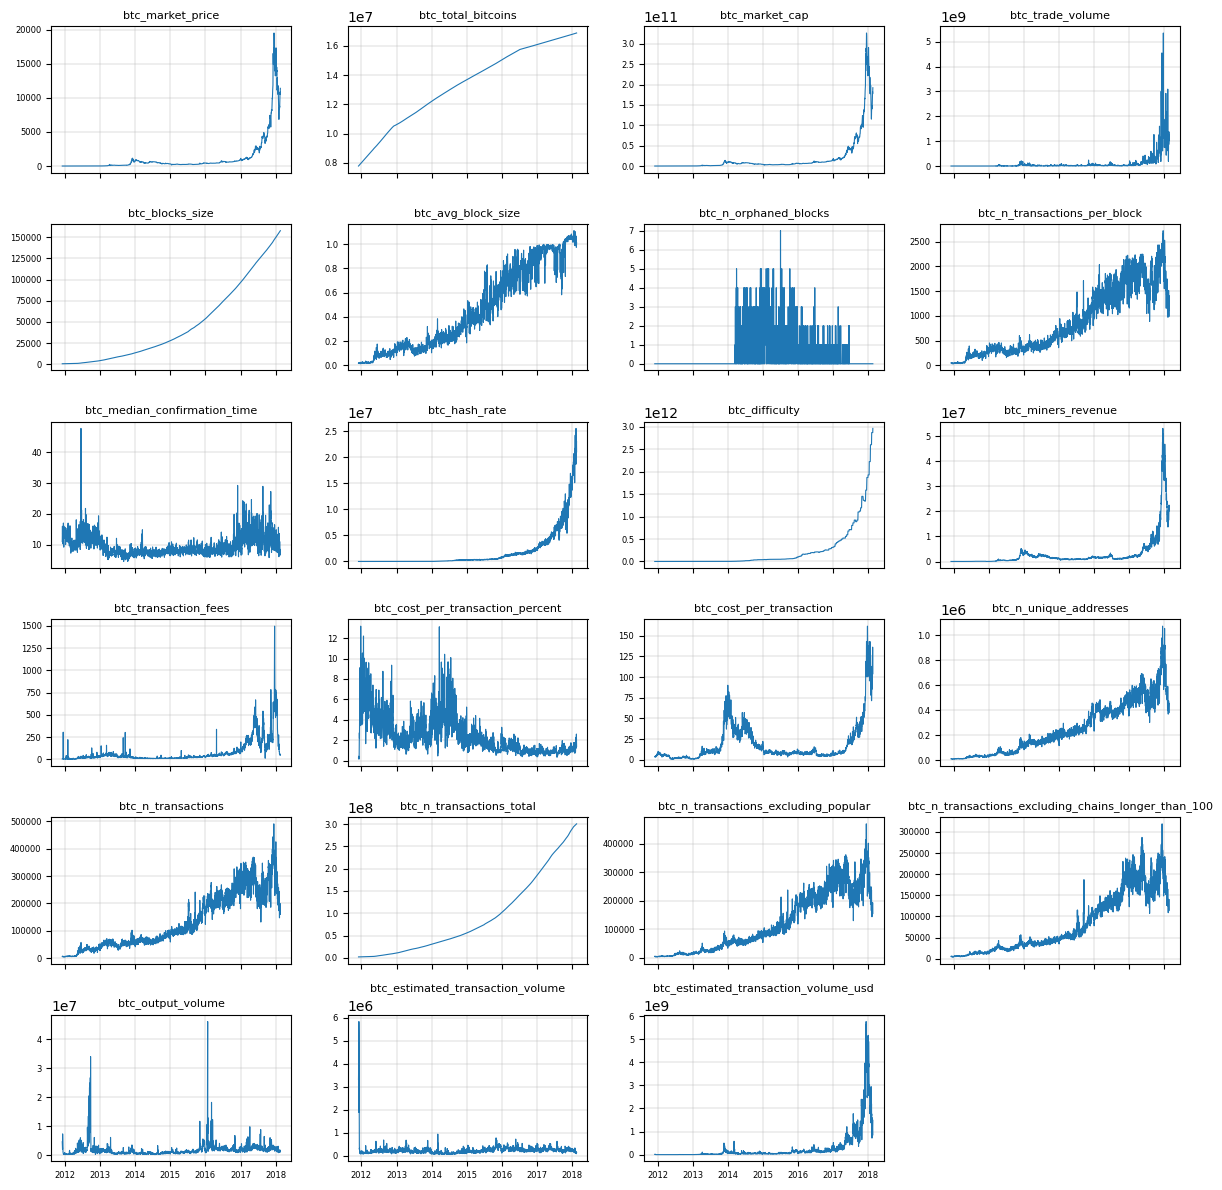

In [15]:
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])
num_cols = bitcoin_df.select_dtypes(include="number").columns

# Grid setup: 4 columns wide, fewer inches per subplot
ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

# Make figure smaller: width = 3 per column, height = 2 per row
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2*nrows), sharex=True)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].plot(bitcoin_df['Date'], bitcoin_df[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis="x", labelsize=6)
    axes[i].tick_params(axis="y", labelsize=6)
    axes[i].grid(True, linewidth=0.3)

# Remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The instructions state there may be scaling issues. To check for this I'm going to create historgrams for each variable. 


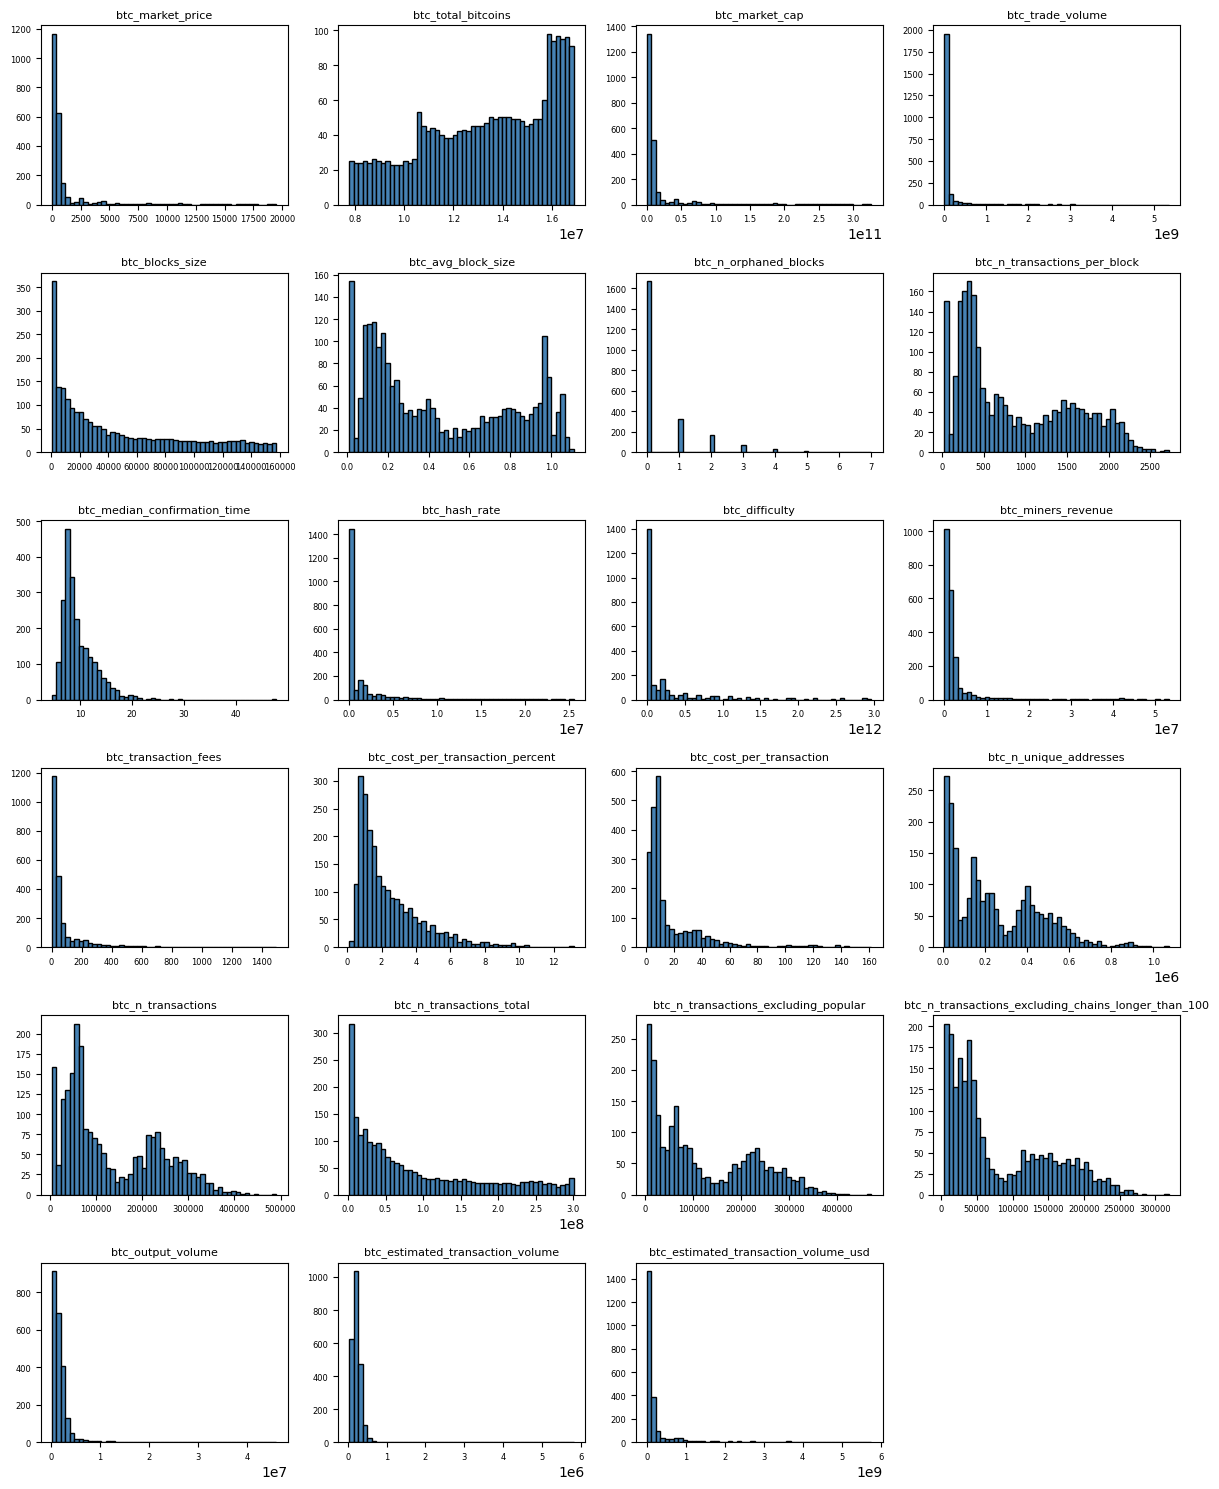

In [16]:
num_cols = bitcoin_df.select_dtypes(include="number").columns

# Grid setup: 4 columns wide
ncols = 4
nrows = math.ceil(len(num_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2.5*nrows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(bitcoin_df[col].dropna(), bins=50, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{col}", fontsize=8)
    axes[i].tick_params(axis="x", labelsize=6)
    axes[i].tick_params(axis="y", labelsize=6)

# Remove unused axes (in case #cols not divisible by ncols)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Transform Highly Skewed Data

In [17]:
skewed_cols = [
    'btc_market_price','btc_market_cap','btc_trade_volume',
    'btc_miners_revenue','btc_transaction_fees','btc_cost_per_transaction',
    'btc_estimated_transaction_volume_usd','btc_output_volume'
]

# Perform a log-transform
for col in skewed_cols:
    bitcoin_df[f'log_{col}'] = np.log1p(bitcoin_df[col])


In [18]:
# Drop the skewed columns now that we hve new ones that have been tranformed
bitcoin_df.drop(columns=skewed_cols, inplace=True)

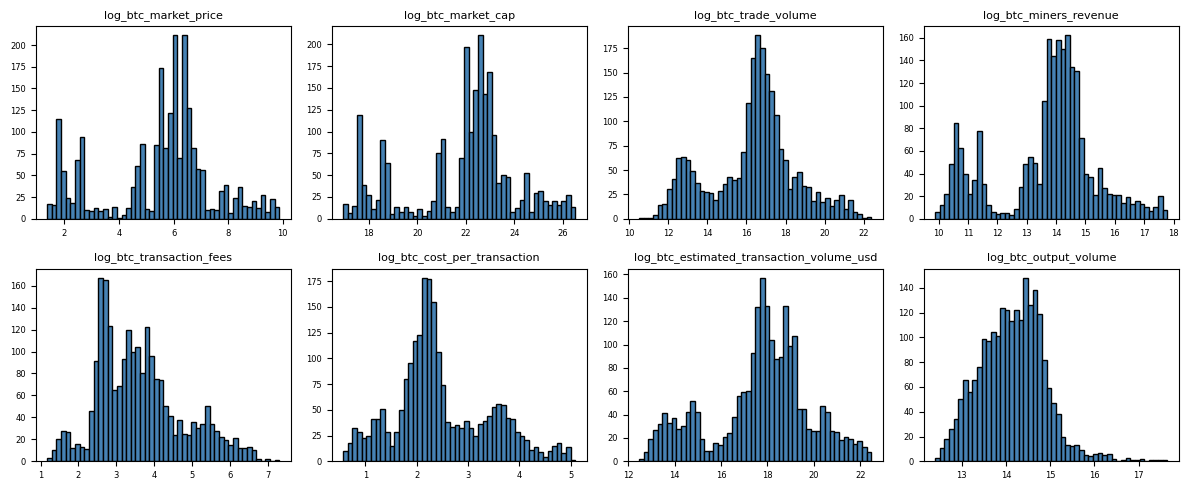

In [19]:
# Plot the new columns
log_cols = [col for col in bitcoin_df.columns if "log_" in col]

# Grid setup: 4 columns wide
ncols = 4
nrows = math.ceil(len(log_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2.5*nrows))

axes = axes.flatten()

for i, col in enumerate(log_cols):
    axes[i].hist(bitcoin_df[col].dropna(), bins=50, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{col}", fontsize=8)
    axes[i].tick_params(axis="x", labelsize=6)
    axes[i].tick_params(axis="y", labelsize=6)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Create Lag Variables

In [20]:
features = [f for f in bitcoin_df.columns if f != "Date"] # Create lags for everything but Date

# Create 1, 2, and 3 lags
lags = [1, 2, 3]

for col in features:
    for lag in lags:
        bitcoin_df[f'{col}_lag_{lag}'] = bitcoin_df[col].shift(lag)

In [21]:
# Set up the target (next day price)
bitcoin_df['target'] = bitcoin_df['log_btc_market_price'].shift(-1)

In [22]:
# Drop rows with NaNs caused by lagging
max_lag = max(lags)
bitcoin_df = bitcoin_df.iloc[max_lag:-1] 

## Train/Test Split

In [23]:
# Select predictor columns for modeling
lagged_features = [col for col in bitcoin_df.columns if 'lag' in col]
X = bitcoin_df[lagged_features]
y = bitcoin_df['target']

In [24]:
# Chronological train/test split
split_idx = int(len(bitcoin_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1815, 69) (1815,)
Test shape: (454, 69) (454,)


In [25]:
# Export train features and target
X_train.to_csv('data/bitcoin_X_train.csv', index=False)
y_train.to_csv('data/bitcoin_y_train.csv', index=False)

# Export test features and target
X_test.to_csv('data/bitcoin_X_test.csv', index=False)
y_test.to_csv('data/bitcoin_y_test.csv', index=False)

print("Datasets exported successfully!")

Datasets exported successfully!
